# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
TODO: Explain in your own words what LLMs are and what kinds of tasks they are designed to solve.
LLM is a machine learning model that can predict next word by given input words/sentences.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [1]:
%pip install --quiet transformers matplotlib --upgrade


^C
Traceback (most recent call last):
  File "/Users/jingjingzhao/Projects/DI-Bootcacmp/.venv/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 109, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "/Users/jingjingzhao/Projects/DI-Bootcacmp/.venv/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 102, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jingjingzhao/Projects/DI-Bootcacmp/.venv/lib/python3.11/site-packages/pip/_internal/cli/req_command.py", line 101, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jingjingzhao/Projects/DI-Bootcacmp/.venv/lib/python3.11/site-packages/pip/_internal/commands/install.py", line 556, in run
    installed = install_given_reqs(
                ^^^^^^^^^^^^^^^^^^^
  File "/Users/jingjingzhao/Projects/DI-Bootcacmp/.venv/lib/python3.11/site-packages/pip/_internal/req/__init__.py", line 8

### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = 'gpt2'  # TODO: choose a causal LM checkpoint, e.g., 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)   # TODO: load AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)       # TODO: load AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")


/Users/jingjingzhao/Projects/DI-Bootcacmp/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-14 18:54:39.061872: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


TODO: Describe the tokenization process in your own words before coding.
tokenization is to split sentence into chunk of words or part of words and each token is pre-assigned to a number/token IDs, so that it can be feed to models for following processing.

Original Text: I live in Tel Aviv.
Tokens: ['I', 'Ġlive', 'Ġin', 'ĠTel', 'ĠAviv', '.']
Token IDs: [40, 2107, 287, 12088, 28890, 13]


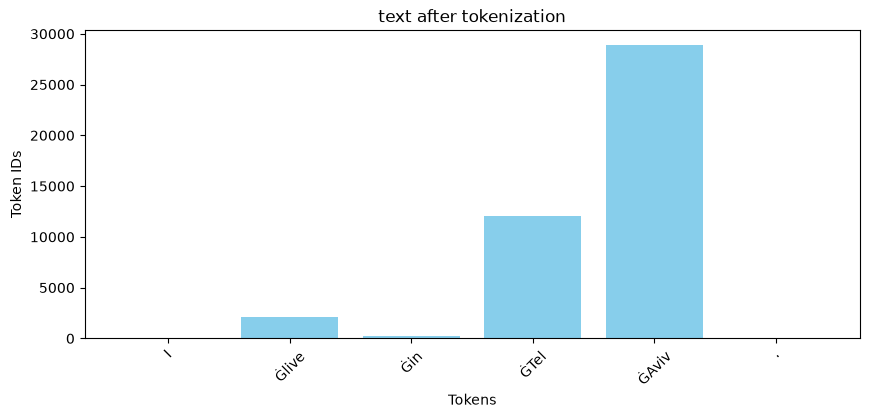

In [2]:
text = 'I live in Tel Aviv.'  # TODO: provide a sentence of your choice
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = 'Tokens'  # TODO: label for the x-axis (e.g., "Tokens")
y_label = 'Token IDs' # TODO: label for the y-axis (e.g., "Token IDs")
title = 'text after tokenization'    # TODO: chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()


## 🌟 Exercise 3 · Token IDs and special prefixes


In [6]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# TODO: print the token along with its numeric id
print(f'Tokens: {tokens}')
print(f'TokenIds: {token_ids}')

# raise NotImplementedError("Iterate over `tokens` and `token_ids`, printing each mapping.")


Tokens: ['I', 'Ġlive', 'Ġin', 'ĠTel', 'ĠAviv', '.']
TokenIds: [40, 2107, 287, 12088, 28890, 13]


TODO: In plain language, explain what the `Ġ` prefix indicates in GPT-style vocabularies.
it represent space.

## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [8]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = 'Lots of things have happened in year 2008, for example'  # TODO: write a brand-new prompt
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: adjust if you want longer/shorter outputs
    "temperature": 0.8,    # TODO: tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: call the generator
output_text = output_ids[0]["generated_text"]     # TODO: extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Input: Lots of things have happened in year 2008, for example
Generated Output: Lots of things have happened in year 2008, for example, the first big global bank event of 2008, and then the global financial crisis, so we see the same things.

How do you do that in a country that has a very different way of thinking about the economy?

It's hard to say. It's always possible to get


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)